In [2]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

35.5+/-3.0
55.6+/-3.0
18.0+/-3.0
20.170+/-4.243
17.441+/-4.243
18.805+/-2.121
18.8+/-2.1


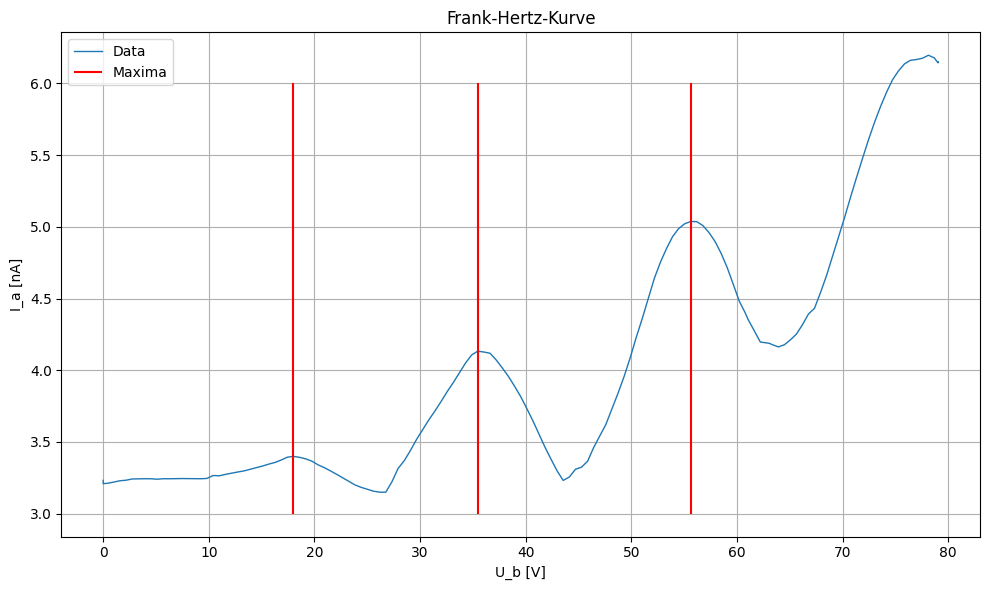

In [34]:
# Franck-Hertz

Data = pd.read_csv("PS9_Di03.csv", sep=';', decimal=',')   # read csv für den Graphen


U_B1 = Data["U_B1"].to_numpy()    # Dehnung Data

U_A1 = Data["U_A1"].to_numpy()*10    # Spannung Data


m1 = ufloat(U_A1[68], 3)
m2 = ufloat(U_A1[103], 3)
m3 = ufloat(U_A1[38], 3)
print(m1)
print(m2)
print(m3)


diff_1 = m2-m1
diff_2 = m1-m3
print(f"{diff_1:.3f}")
print(f"{diff_2:.3f}")
diff = np.mean((diff_1,diff_2))
print(f"{diff:.3f}")
print(diff*c.e/c.eV)

plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(U_A1, U_B1, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel(r"U_b [V]")
plt.vlines((U_A1[68],U_A1[103],U_A1[38]),3,6, colors="r", label="Maxima")
plt.ylabel(r"I_a [nA]")
plt.title("Frank-Hertz-Kurve")
plt.grid()
plt.legend()
plt.tight_layout()



(array([235]),)
585
2.1194+/-0.0072


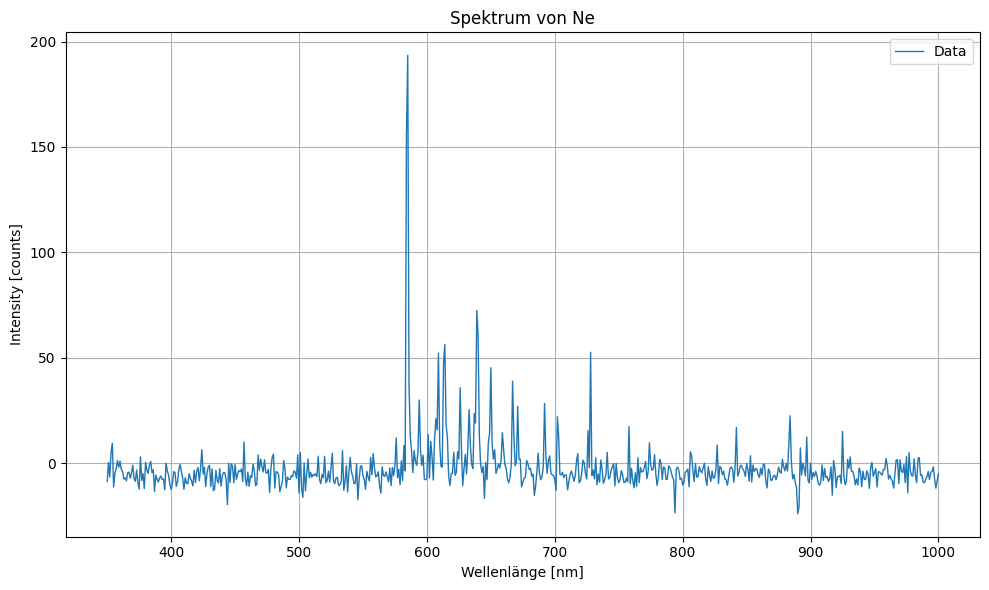

In [43]:
Data = pd.read_csv("PS9-DI03-1.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["int"].to_numpy()    # Dehnung Data

F = Data["Lam"].to_numpy()    # Spannung Data

T[95] = 0
print(np.where(T == max(T)))

print(F[235])

lam_max = ufloat(F[235],2)

delE = c.h*c.c/(lam_max*10**(-9))/c.eV
print(f"{delE:.4f}")

plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(F, T, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("Wellenlänge [nm]")
plt.ylabel("Intensity [counts]")
plt.title("Spektrum von Ne")
plt.grid()
plt.legend()
plt.tight_layout()

In [46]:
U_1 = ufloat(22.2,5)  # V
U_2 = ufloat(41.4,5)
U_3 = ufloat(62.0,5)

delU = np.mean((U_2-U_1,U_3-U_2))
print(f"{delU:.4f}")



19.9000+/-3.5355


In [6]:
#rechnen

U_m_1 = 34
U_m_2 = 56

lam_max = 590

del_U = U_m_2-U_m_1

E_hg = del_U

print(E_hg)

E_hg_l = c.c/(lam_max*10**(-9))*c.h/c.eV
print(c.c)
print(E_hg_l)

22
299792458.0
2.1014270920881395


6.62607015e-34
9.1093837139e-31
0.219+/-0.011
0.219+/-0.011


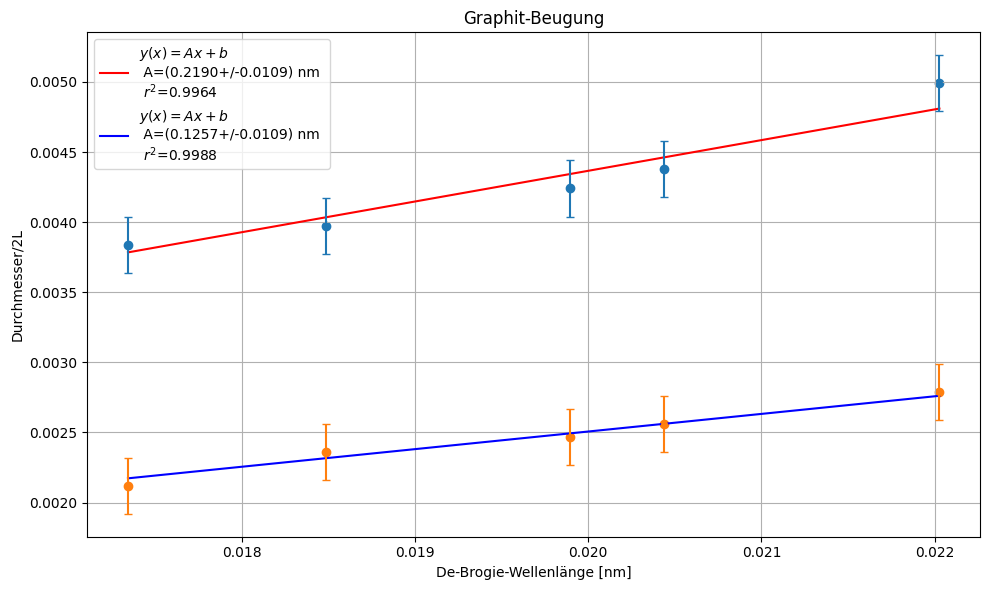

0.055+/-0.005
0.032+/-0.004


In [ ]:
# Elektronenebeugung

L = ufloat(12.57,1)/100 # cm
D_1 = unp.uarray([4.99, 4.38, 4.24, 3.97, 3.84, 0],0.2)/1000 # m
D_2 = unp.uarray([2.79, 2.56, 2.47, 2.36, 2.12, 0],0.2)/1000 # m
U = unp.uarray([3.1, 3.6, 3.8, 4.4, 5.0],0.1)*1000 #V
print(c.h)
print(c.m_e)
def lam(U): 
    return c.h/(unp.sqrt(2*c.m_e*c.e*U))*10**(9)
# def d(U,D,L):
#     return 2*lam(U)*L/D

lam_1 = np.append(lam(unp.nominal_values(U)), 0)
lam_1_u = lam(U)



# print(d(U,D_1,L))

popt, pcov = curve_fit(Helper.linfit, lam_1, unp.nominal_values(D_1), p0=[1, 1], sigma= 0.0002,absolute_sigma=True)

a_opt, b_opt = popt
x_model = np.linspace(min(lam_1[:-1]), max(lam_1), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
A = ufloat(a_opt,perr[0])

print(A)
r2 = Helper.r2_curve_fit(popt, lam_1, unp.nominal_values(D_1), Helper.linfit)



popt_1, pcov_1 = curve_fit(Helper.linfit, lam_1, unp.nominal_values(D_2), p0=[1, 1], sigma= 0.0002,absolute_sigma=True)

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(lam_1[:-1]), max(lam_1), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr_1 = np.sqrt(np.diag(pcov_1))

A_1 = ufloat(a_opt,perr_1[0])

print(A)
r2_1 = Helper.r2_curve_fit(popt_1, lam_1, unp.nominal_values(D_2), Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(lam_1[:-1], unp.nominal_values(D_1)[:-1])
plt.scatter(lam_1[:-1], unp.nominal_values(D_2)[:-1])
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({A:.3f}) nm \n $r^2$={r2:.4f}")
plt.plot(x_model_1, y_model_1, color='b', label=f"$y(x)=Ax+b$ \n A=({A_1:.3f}) nm \n $r^2$={r2_1:.4f}")
plt.errorbar(lam_1[:-1], unp.nominal_values(D_1)[:-1], fmt='o', yerr=0.0002, capsize=3, markersize=4)
plt.errorbar(lam_1[:-1], unp.nominal_values(D_2)[:-1], fmt='o', yerr=0.0002, capsize=3, markersize=4)
# plt.plot(V, p, "o")
plt.ylabel(r"Durchmesser/2L")
plt.xlabel(r"De-Brogie-Wellenlänge [nm]")
plt.legend()
plt.title("Graphit-Beugung")
plt.tight_layout()
plt.grid()
plt.show()


d_1 = A*(2*L)
print(d_1)

d_2 = A_1*(2*L)
print(d_2)